# Seasonal Agriculture Performance Analysis

**Domain:** Agriculture

**Project Theme:** Seasonal Agriculture Performance

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

### Project Goal
Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.


## 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. As a result, agricultural performance may differ from one season to another.

Raw agricultural data does not, on its own, explain how performance changes across seasons or what patterns exist within different seasonal conditions. This project analyzes the given agricultural dataset to investigate seasonal differences in performance by identifying meaningful patterns, trends, relationships and variations, and to communicate findings based on evidence from the data.

## 2. Project Objectives

- Understand the structure and quality of the agricultural dataset.
- Clean and prepare the data for analysis.
- Explore seasonal patterns in the dataset.
- Perform descriptive and statistical analysis.
- Investigate relationships among relevant variables.
- Compare agricultural performance across seasons and other meaningful groups.
- Use appropriate univariate, bivariate and multivariate visualizations.
- Identify significant findings from the data.
- Develop evidence-based insights and recommendations.

## 3. Dataset

The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit and resource usage.

**Dataset file:** `seasonal_agriculture_performance_dataset.csv`

## 4.SetUp

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns",None)
pd.set_option("display.float_format",lambda x:f"{x:,.2f}")

### 4.1 Dataset Loaded Successfully

In [5]:
df=pd.read_csv("D:\Shruti Halle\Seasonal Agriculture Performance Analysis\seasonal_agriculture_performance_dataset.csv")
print("Dataset loaded sucessfully")

Dataset loaded sucessfully


### 4.2 Dataset Shape and Structure

In [7]:
# Dataset Shape
print("No of Rows:",df.shape[0])
print("No of Columns:",df.shape[1])

No of Rows: 4000
No of Columns: 28


### 4.3 Top 5 Rows

In [6]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [8]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [9]:
# random sample of records
df.sample(5,random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,"1,213.70",26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


In [10]:
#Column names
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


### 4.4 Data Types

In [11]:
#Data types & non_null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [12]:
#Numerical summary statistics
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,"4,000.00","3,952.00","4,000.00","4,000.00","4,000.00","4,000.00","3,960.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","3,968.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,"44,714.17","526,303.58","637,860.05","111,556.46","6,045.57",5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,"30,266.16","294,419.14","636,974.71","545,081.89","5,572.94",8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,"2,594.00","26,826.00","6,107.00","-1,019,223.00",128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,"21,429.25","274,577.50","207,517.25","-148,731.75","2,268.75",1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,"25,913.00","519,082.50","456,830.50","3,673.00","4,435.00",2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,"68,279.00","761,996.50","836,874.75","216,187.75","7,829.75",5.15,54.90
max,15.00,"1,395.20",39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,"1,424.40","131,240.00","1,349,990.00","5,080,900.00","4,345,421.00","40,902.00",79.80,88.90


In [13]:
# Categorical summary
df.describe(include="object")

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF10001,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


## 5.Data Quanlity Analysis

###  Missing Values — Identified and Handled

In [14]:
# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_percentage.round(2)
})

missing_summary[missing_summary["Missing_Count"] > 0]

,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


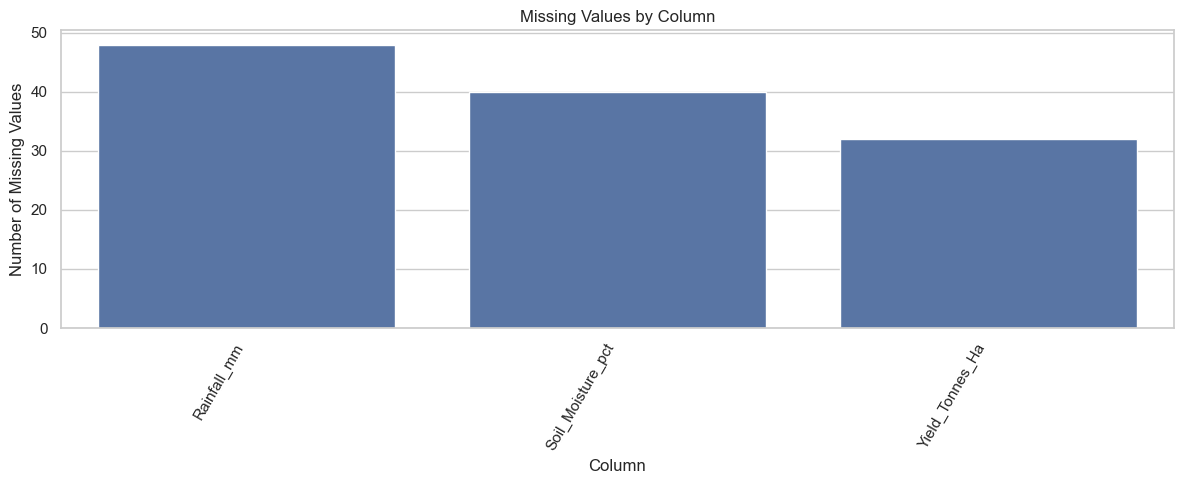

In [ ]:
# Visualize missing values
plt.figure(figsize=(12, 5))
missing_plot = missing[missing > 0]
if len(missing_plot) > 0:
    sns.barplot(x=missing_plot.index, y=missing_plot.values)
    plt.xticks(rotation=60, ha="right")
    plt.ylabel("Number of Missing Values")
    plt.xlabel("")
    plt.title("Missing Values by Column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

In [16]:
# Duplicate records
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


### Duplicate Records — Identified and Handled

In [19]:
#Remove duplicate rowa
df=df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates",df.shape)

Shape after removing duplicates (4000, 28)


In [21]:
#Check data type again
df.dtypes

Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Profit_INR      

In [22]:
# Check unique values for categorical columns
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].nunique(), "unique values")
    print(df[col].dropna().unique()[:20])


Farm_ID:
4000 unique values
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State:
8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
3 unique values
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [24]:
#Checking missing values after duplicates removal
df.isnull().sum().sort_values(ascending=False).head(10)

Rainfall_mm                      48
Soil_Moisture_pct                40
Yield_Tonnes_Ha                  32
Farm_ID                           0
Irrigation_Method                 0
Water_Efficiency_t_per_1000m3     0
Water_Used_m3                     0
Profit_INR                        0
Revenue_INR                       0
Total_Cost_INR                    0
dtype: int64

### Missing Value Strategy

All three columns with missing data — Rainfall_mm (1.2%), Soil_Moisture_pct (1.0%),
and Yield_Tonnes_Ha (0.8%) — are numerical and have low missingness (under 2%).

Approach: median imputation.
- Median is preferred over mean because these variables can contain outliers
  (e.g. extreme rainfall events), and median is resistant to skew.
- No records were dropped, since missingness is low and dropping rows would
  also discard other valid, complete columns in the same rows.
- No categorical columns had missing values, so no category-fill was needed.

In [25]:
# Check whether missingness is random or clustered by Season
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    print(f"\nMissing {col} by Season:")
    print(df[df[col].isna()]['Season'].value_counts())


Missing Rainfall_mm by Season:
Season
Kharif    19
Rabi      18
Zaid      11
Name: count, dtype: int64

Missing Soil_Moisture_pct by Season:
Season
Kharif    18
Rabi      13
Zaid       9
Name: count, dtype: int64

Missing Yield_Tonnes_Ha by Season:
Season
Rabi      20
Kharif     7
Zaid       5
Name: count, dtype: int64


## 6.Feature Analysis

In [26]:
# Yield_Tonnes_Ha: missingness is disproportionately concentrated in Rabi (62.5% of
# missing values vs 40.7% expected), so use season-wise median instead of a global
# median to avoid biasing Rabi's yield distribution toward the overall average.
df['Yield_Tonnes_Ha'] = df.groupby('Season')['Yield_Tonnes_Ha'].transform(
    lambda x: x.fillna(x.median())
)

# Rainfall_mm and Soil_Moisture_pct: missingness is only mildly skewed (Zaid slightly
# overrepresented), so a global median fill is acceptable here.
for col in ['Rainfall_mm', 'Soil_Moisture_pct']:
    df[col] = df[col].fillna(df[col].median())

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


In [27]:
# Numerical and categorical columns

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


## 7.Statistical Analysis

In [28]:
# Descriptive statistics

stats = df[numeric_columns].describe().T
stats["range"] = stats["max"] - stats["min"]
stats["IQR"] = stats["75%"] - stats["25%"]

stats

,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00,14.50,7.39
Rainfall_mm,"4,000.00",600.92,287.19,80.00,371.58,582.00,831.98,"1,395.20","1,315.20",460.40
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70,23.50,5.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00,70.00,17.13
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,1.50
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,0.88
Soil_Moisture_pct,"4,000.00",26.51,6.68,8.00,21.80,26.40,31.20,47.00,39.00,9.40
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00,180.00,42.72
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00,105.00,23.20
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00,170.00,37.40


In [29]:
# Median and standard deviation

statistical_summary = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Std_Dev": df[numeric_columns].std(),
    "Min": df[numeric_columns].min(),
    "Max": df[numeric_columns].max()
})

statistical_summary

,Mean,Median,Std_Dev,Min,Max
Farm_Area_Hectares,7.89,7.89,4.22,0.50,15.00
Rainfall_mm,600.92,582.00,287.19,80.00,"1,395.20"
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.68,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


In [30]:
# Seasonal descriptive summary

season_summary = df.groupby("Season")[numeric_columns].agg(["mean", "median", "std"])
season_summary

Farm_Area_Hectares             Rainfall_mm                \
                     mean median  std        mean median    std   
Season                                                            
Kharif               7.94   8.18 4.28      849.20 853.10 183.69   
Rabi                 7.75   7.68 4.18      437.62 432.20 175.35   
Zaid                 8.09   8.09 4.16      304.65 288.20 157.24   

       Avg_Temperature_C             Humidity_pct              \
                    mean median  std         mean median  std   
Season                                                          
Kharif             28.45  28.50 2.51        71.81  71.90 8.86   
Rabi               23.49  23.50 2.46        57.89  58.10 9.00   
Zaid               31.04  31.00 2.55        52.01  52.35 9.05   

       Sunlight_Hours_Day             Soil_pH             Soil_Moisture_pct  \
                     mean median  std    mean median  std              mean   
Season                                                                        
Kharif               6.79   6.80 0.98    6.73   6.73 0.64             31.15   
Rabi                 7.59   7.60 1.00    6.67   6.67 0.64             24.07   
Zaid                 8.18   8.20 1.05    6.69   6.66 0.64             19.28   

                   Nitrogen_kg_ha              Phosphorus_kg_ha               \
       median  std           mean median   std             mean median   std   
Season                                                                         
Kharif  31.10 5.04         120.02 119.80 31.18            58.10  57.40 17.15   
Rabi    24.00 4.94         120.40 120.30 31.10            57.31  57.70 17.12   
Zaid    19.10 4.94         120.53 120.15 31.70            58.13  57.45 16.29   

       Potassium_kg_ha              Fertilizer_kg_ha               \
                  mean median   std             mean median   std   
Season                                                              
Kharif          105.30 104.80 27.03           187.08 188.20 60.82   
Rabi            103.93 104.80 28.87           185.41 185.30 59.95   
Zaid            105.42 106.30 26.66           184.64 183.95 59.47   

       Pesticide_Litre_ha             Seed_Quality_Score              \
                     mean median  std               mean median  std   
Season                                                                 
Kharif               5.08   5.18 1.96               0.82   0.82 0.10   
Rabi                 5.02   5.02 1.99               0.83   0.84 0.10   
Zaid                 5.17   5.19 1.99               0.82   0.83 0.10   

       Yield_Tonnes_Ha              Production_Tonnes                \
                  mean median   std              mean median    std   
Season                                                                
Kharif            5.63   1.95 14.39             46.31  13.24 135.70   
Rabi              5.04   1.66 12.75             41.49  11.08 121.90   
Zaid              4.64   1.45 11.27             38.89   9.97 112.00   

       Market_Price_INR_Tonne                     Total_Cost_INR             \
                         mean    median       std           mean     median   
Season                                                                        
Kharif              44,850.91 25,793.00 30,301.56     531,804.41 524,840.00   
Rabi                44,747.97 26,041.00 30,309.56     513,836.58 506,733.00   
Zaid                44,212.03 25,749.50 30,086.23     543,976.73 534,833.00   

                  Revenue_INR                       Profit_INR             \
              std        mean     median        std       mean     median   
Season                                                                      
Kharif 298,487.69  710,719.06 520,196.00 708,710.37 178,914.65  38,808.00   
Rabi   288,386.89  601,526.05 438,156.00 584,545.52  87,689.47  -3,187.00   
Zaid   297,576.86  519,171.90 373,700.50 509,524.55 -24,804.82 -62,144.00   

                  Water_Used_m3             

## 8.Unvariant Analysis

### Categorical 

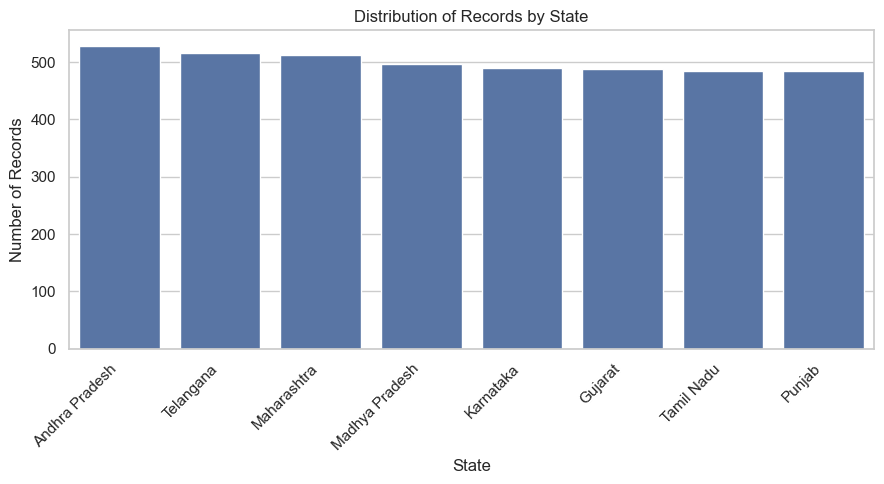

In [31]:
# Univariate: State distribution
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="State", order=df["State"].value_counts().index)
plt.title("Distribution of Records by State")
plt.xlabel("State")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

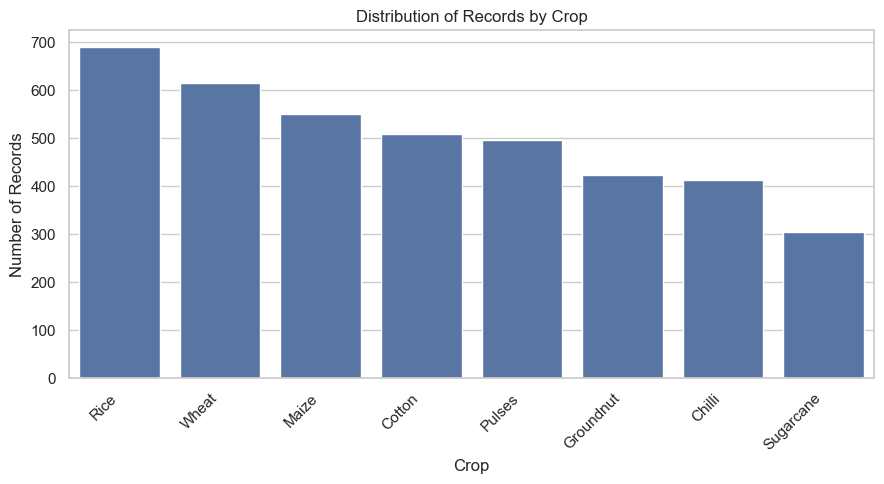

In [32]:
# Univariate: Crop distribution
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="Crop", order=df["Crop"].value_counts().index)
plt.title("Distribution of Records by Crop")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

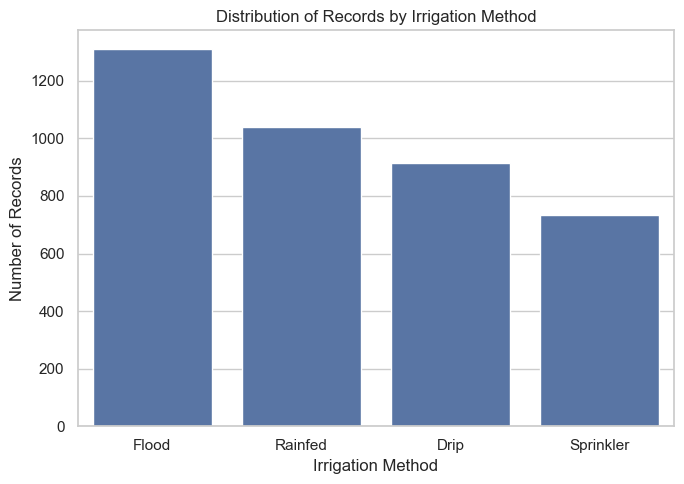

In [33]:
# Univariate: Irrigation method distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Irrigation_Method", order=df["Irrigation_Method"].value_counts().index)
plt.title("Distribution of Records by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

### Numerical / performance distributions

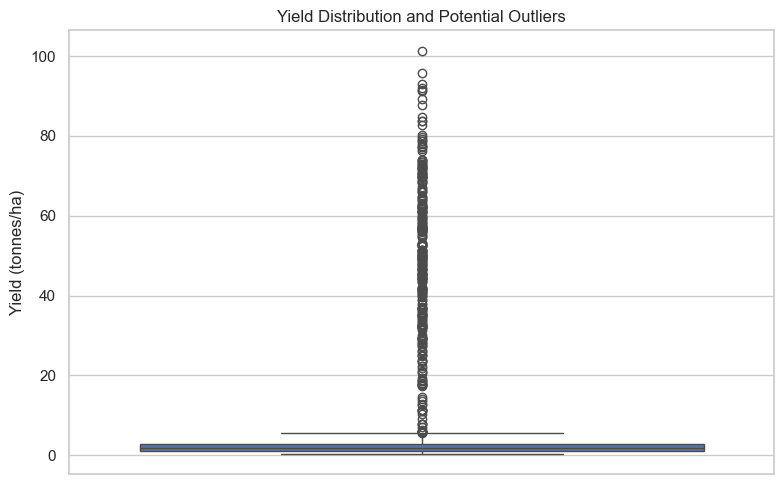

In [39]:
# Univariate: Boxplot for yield
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, y="Yield_Tonnes_Ha")
plt.title("Yield Distribution and Potential Outliers")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

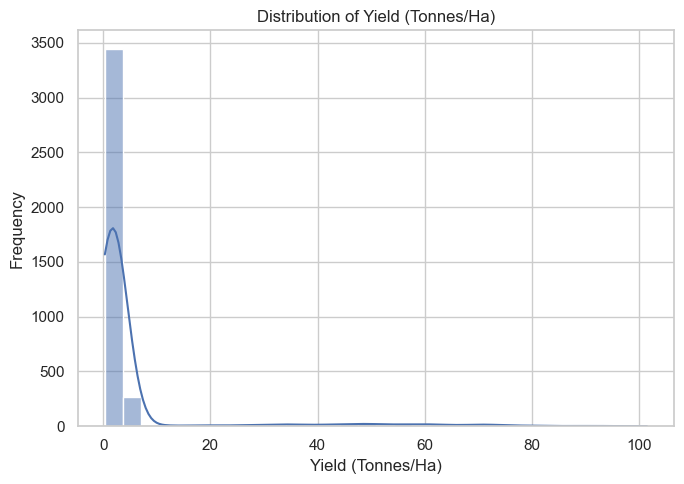

In [34]:
# Univariate: Yield distribution
plt.figure(figsize=(7, 5))
sns.histplot(df["Yield_Tonnes_Ha"], kde=True, bins=30)
plt.title("Distribution of Yield (Tonnes/Ha)")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

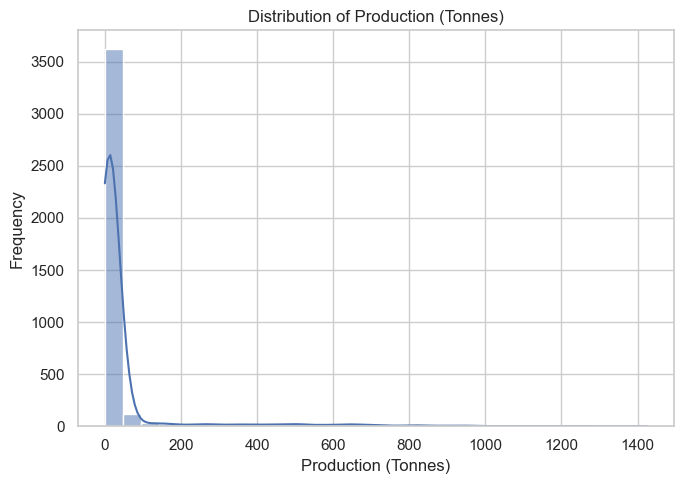

In [35]:
# Univariate: Production distribution
plt.figure(figsize=(7, 5))
sns.histplot(df["Production_Tonnes"], kde=True, bins=30)
plt.title("Distribution of Production (Tonnes)")
plt.xlabel("Production (Tonnes)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

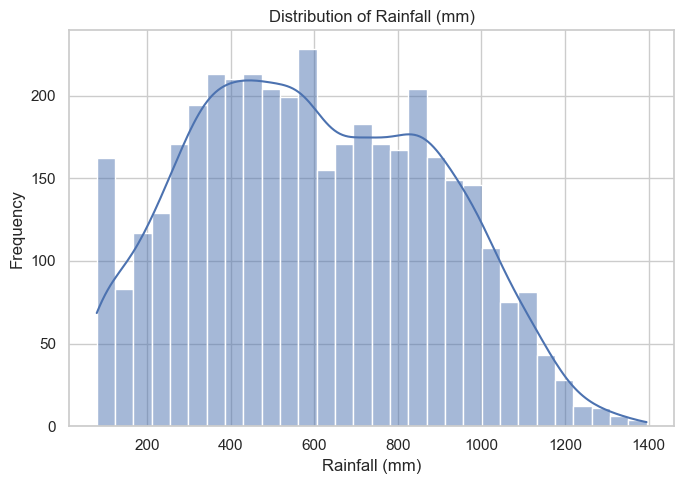

In [36]:
# Univariate: Rainfall distribution
plt.figure(figsize=(7, 5))
sns.histplot(df["Rainfall_mm"], kde=True, bins=30)
plt.title("Distribution of Rainfall (mm)")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Economic distributions

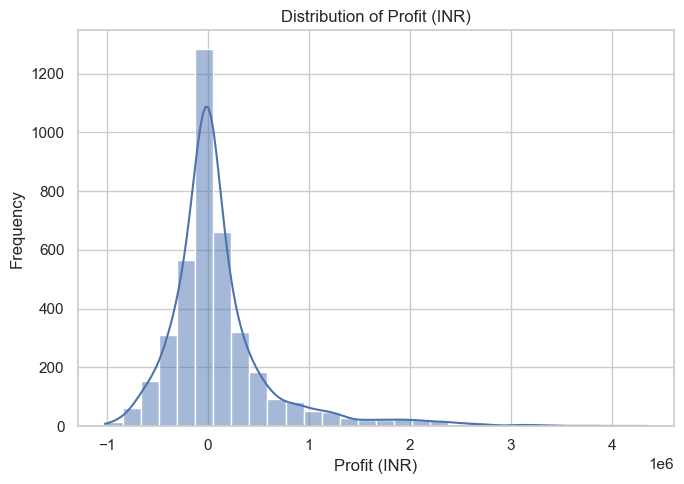

In [37]:
# Univariate: Profit distribution
plt.figure(figsize=(7, 5))
sns.histplot(df["Profit_INR"], kde=True, bins=30)
plt.title("Distribution of Profit (INR)")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

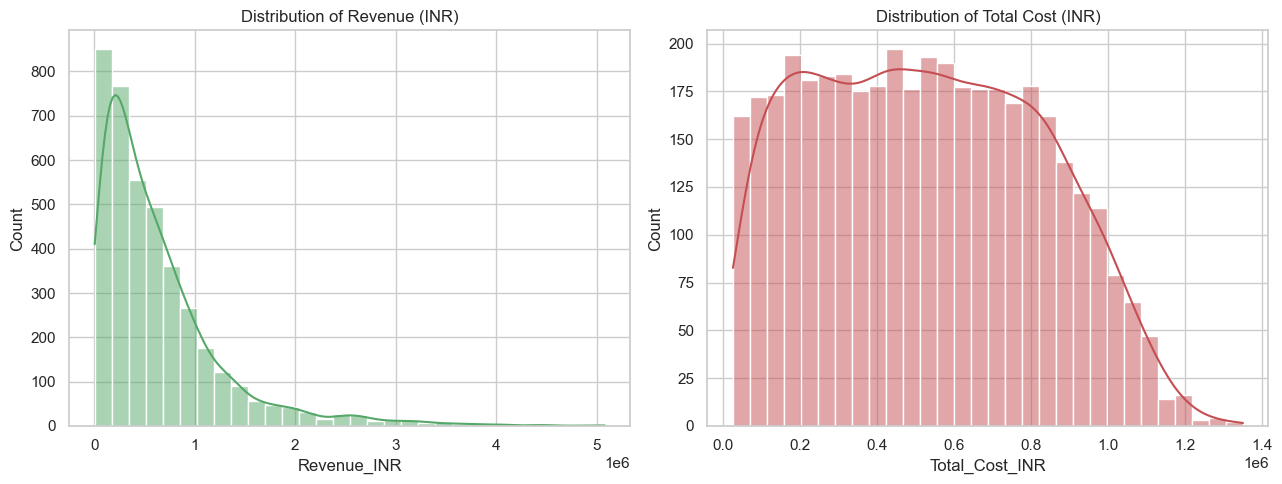

In [38]:
# Univariate: Revenue vs Cost distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df["Revenue_INR"], kde=True, bins=30, ax=axes[0], color="#55A868")
axes[0].set_title("Distribution of Revenue (INR)")
sns.histplot(df["Total_Cost_INR"], kde=True, bins=30, ax=axes[1], color="#C44E52")
axes[1].set_title("Distribution of Total Cost (INR)")
plt.tight_layout()
plt.show()

# 9.Outliers

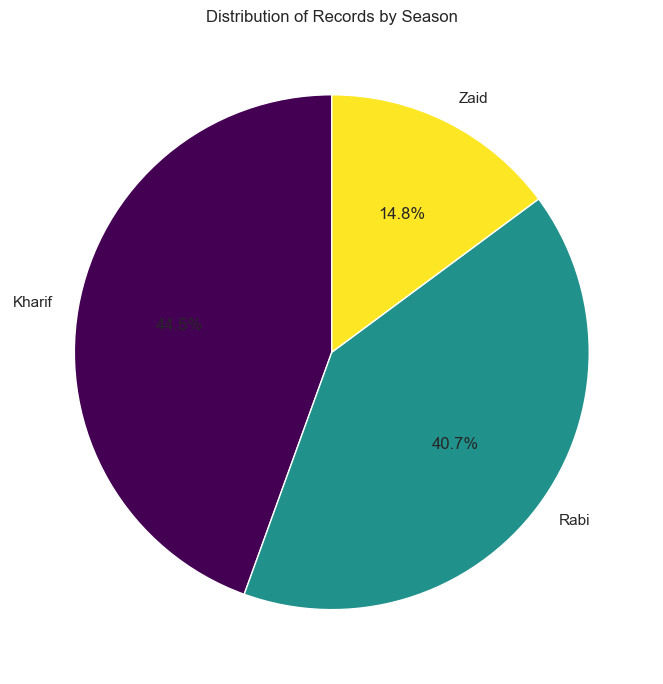

In [40]:
plt.figure(figsize=(7, 7))
df['Season'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis')
plt.title('Distribution of Records by Season')
plt.ylabel('')  # Hide the default 'Season' label on the y-axis
plt.tight_layout()
plt.show()

In [42]:
# Outlier detection using IQR method
outlier_summary = []

for col in numeric_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Column": col,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": count,
        "Outlier_Percentage": round(count / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values(
    "Outlier_Count", ascending=False
)

outlier_summary

,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
18,Profit_INR,"-696,111.00","763,567.00",404,10.10
14,Production_Tonnes,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,-1.62,5.50,302,7.55
19,Water_Used_m3,"-6,072.75","16,171.25",276,6.90
17,Revenue_INR,"-736,519.00","1,780,911.00",240,6.00
9,Potassium_kg_ha,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,19.14,352.04,15,0.38


# 10. Bivariate Analysis

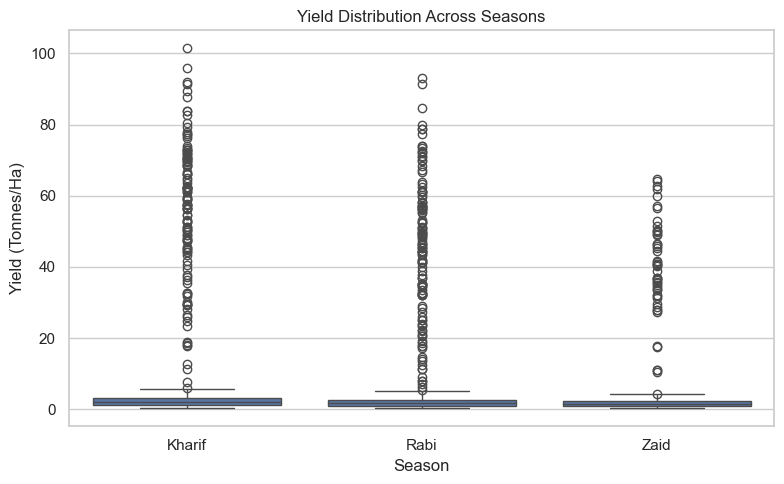

In [43]:
# Bivariate: Season vs Yield
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha")
plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

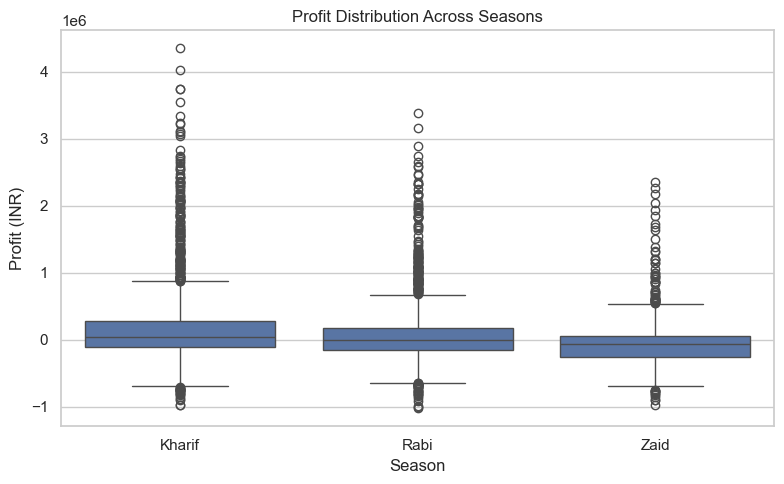

In [45]:
# Bivariate: Season vs Profit
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Profit_INR")
plt.title("Profit Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

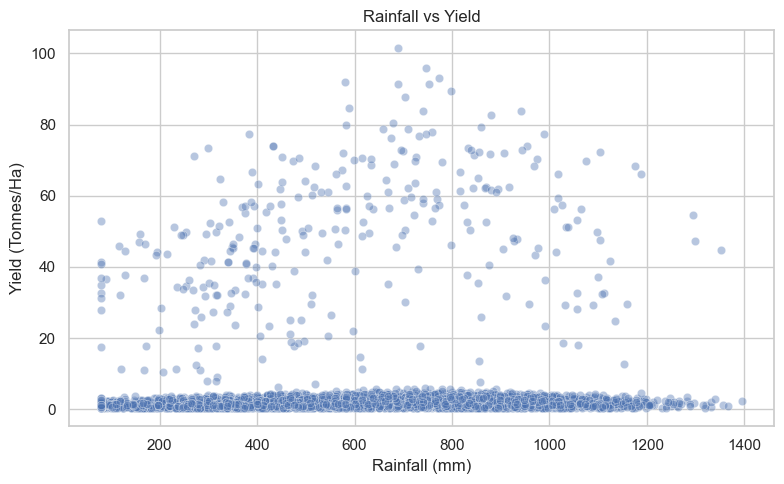

In [46]:
# Bivariate: Rainfall vs Yield
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", alpha=0.4)
plt.title("Rainfall vs Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

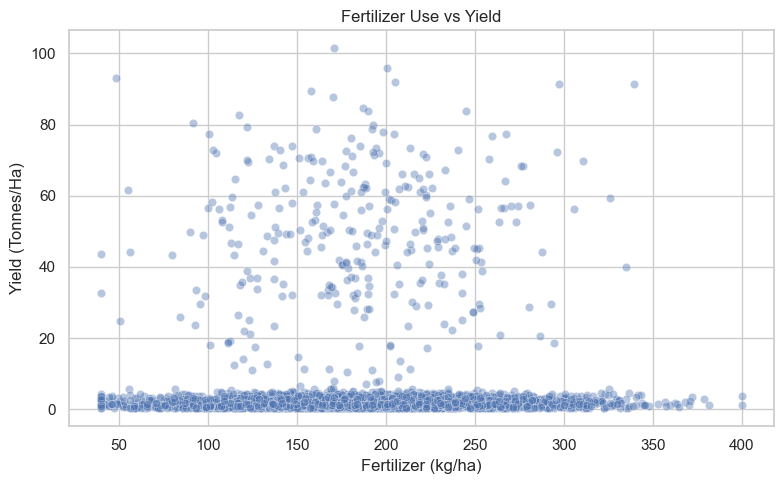

In [47]:
# Bivariate: Fertilizer vs Yield
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Fertilizer_kg_ha", y="Yield_Tonnes_Ha", alpha=0.4)
plt.title("Fertilizer Use vs Yield")
plt.xlabel("Fertilizer (kg/ha)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

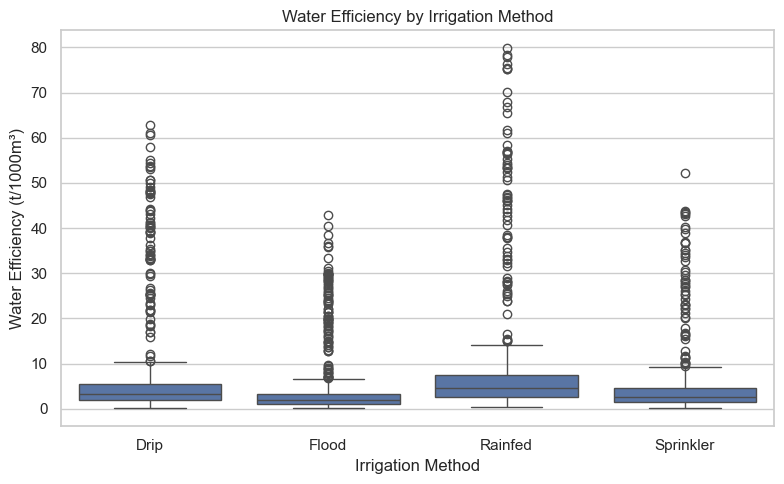

In [48]:
# Bivariate: Irrigation Method vs Water Efficiency
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Irrigation_Method", y="Water_Efficiency_t_per_1000m3")
plt.title("Water Efficiency by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Water Efficiency (t/1000m³)")
plt.tight_layout()
plt.show()

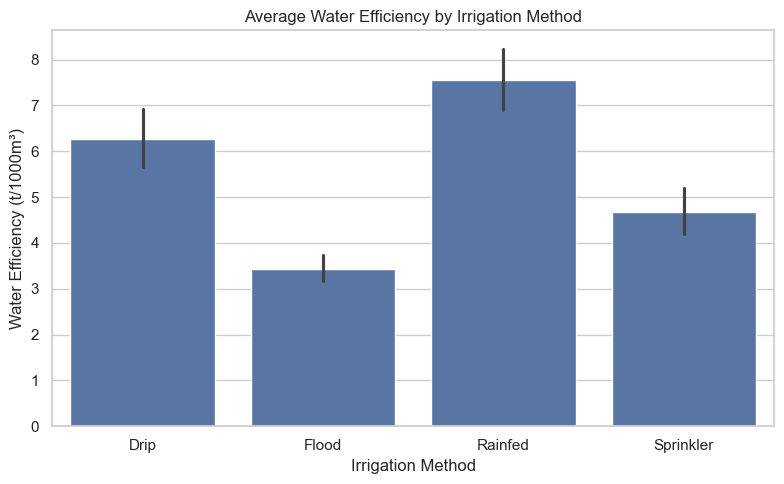

In [51]:
# Bivariate: Irrigation Method vs Water Efficiency (Bar Chart)
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Irrigation_Method", y="Water_Efficiency_t_per_1000m3", estimator="mean")
plt.title("Average Water Efficiency by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Water Efficiency (t/1000m³)")
plt.tight_layout()
plt.show()

# 11. Multivariate Analysis

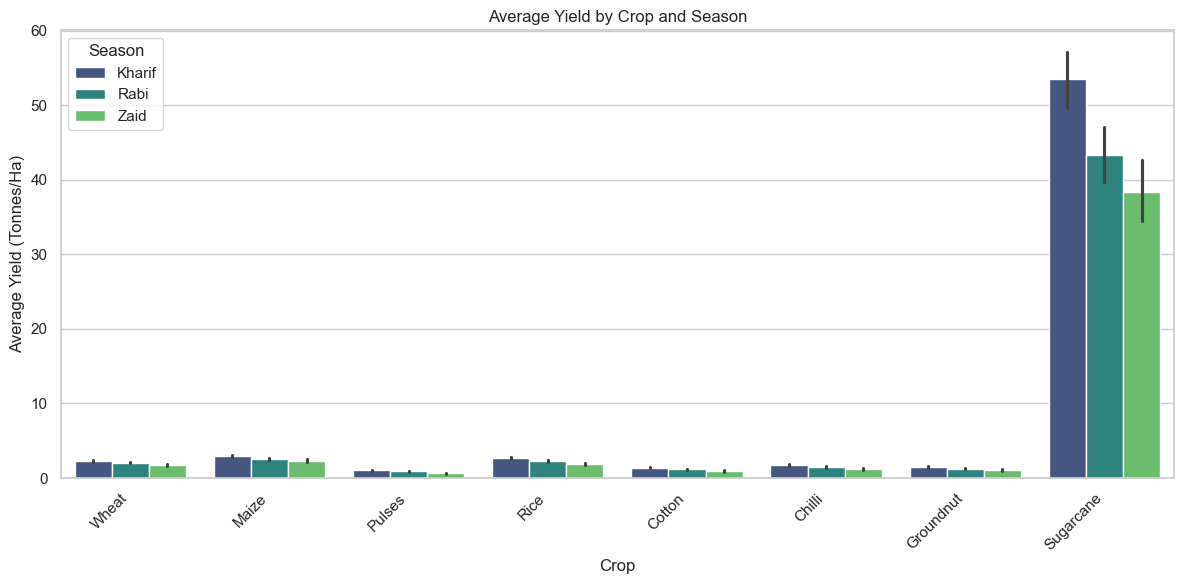

In [54]:
# Multivariate: Average Yield by Crop and Season (Bar Chart)
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x="Crop", y="Yield_Tonnes_Ha", hue="Season", palette="viridis")
plt.xticks(rotation=45, ha="right")
plt.title("Average Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

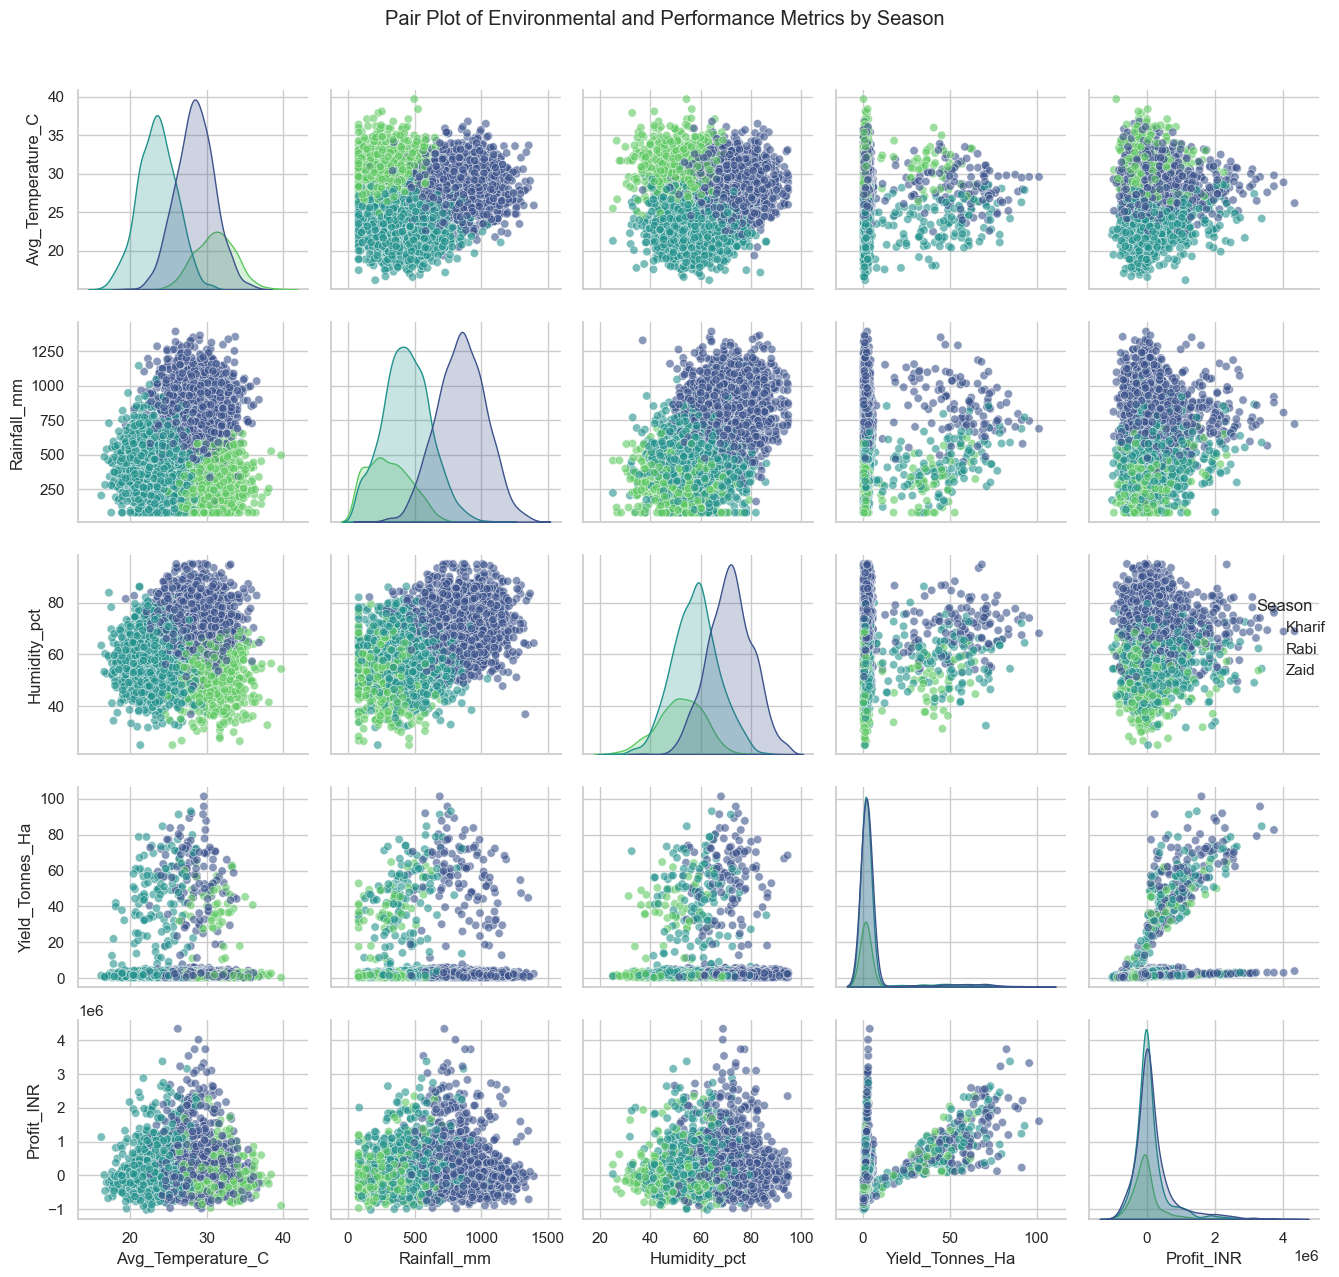

In [53]:
selected_columns = ['Avg_Temperature_C', 'Rainfall_mm', 'Humidity_pct', 'Yield_Tonnes_Ha', 'Profit_INR', 'Season']
sns.pairplot(df[selected_columns], hue='Season', palette='viridis', plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot of Environmental and Performance Metrics by Season', y=1.02)  # Adjust suptitle position
plt.tight_layout()
plt.show()

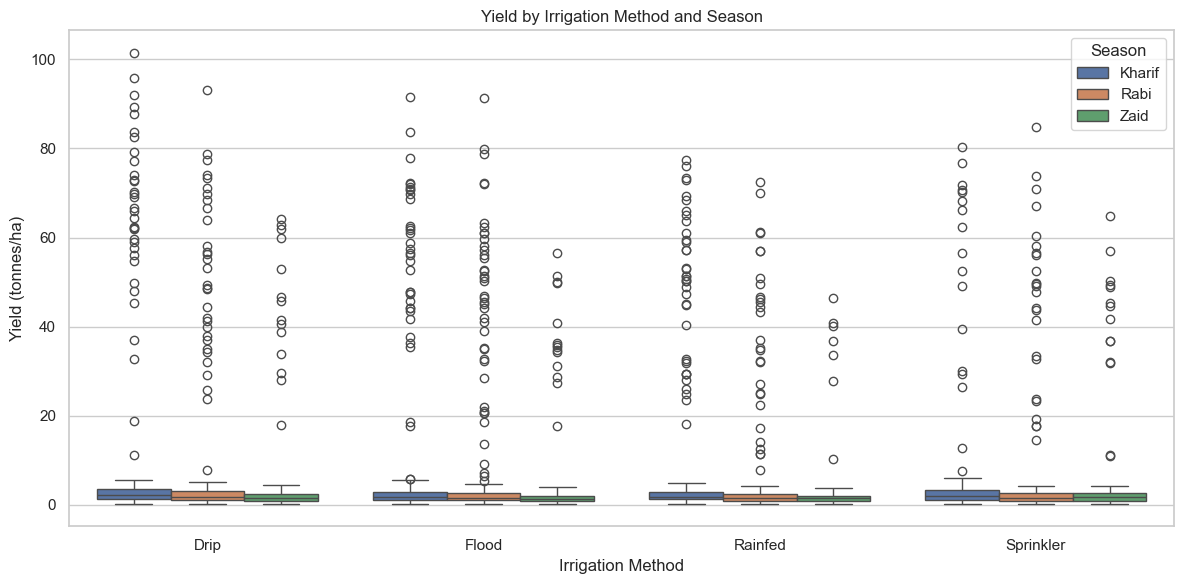

In [55]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", hue="Season")
plt.title("Yield by Irrigation Method and Season")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

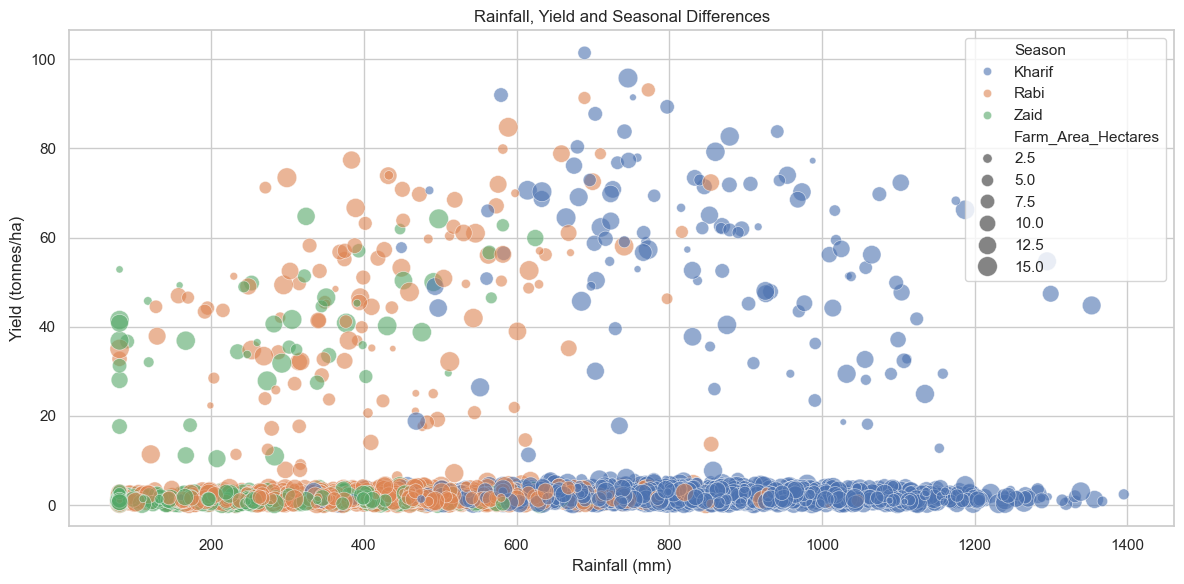

In [56]:
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 200),
    alpha=0.6
)
plt.title("Rainfall, Yield and Seasonal Differences")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

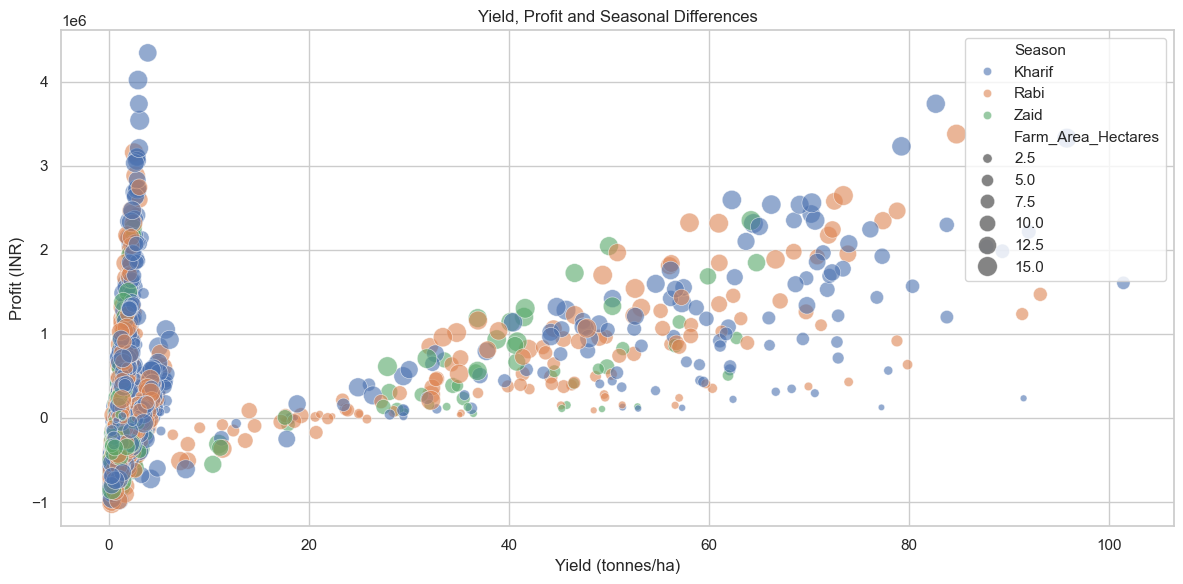

In [57]:

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df,
    x="Yield_Tonnes_Ha",
    y="Profit_INR",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 200),
    alpha=0.6
)
plt.title("Yield, Profit and Seasonal Differences")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

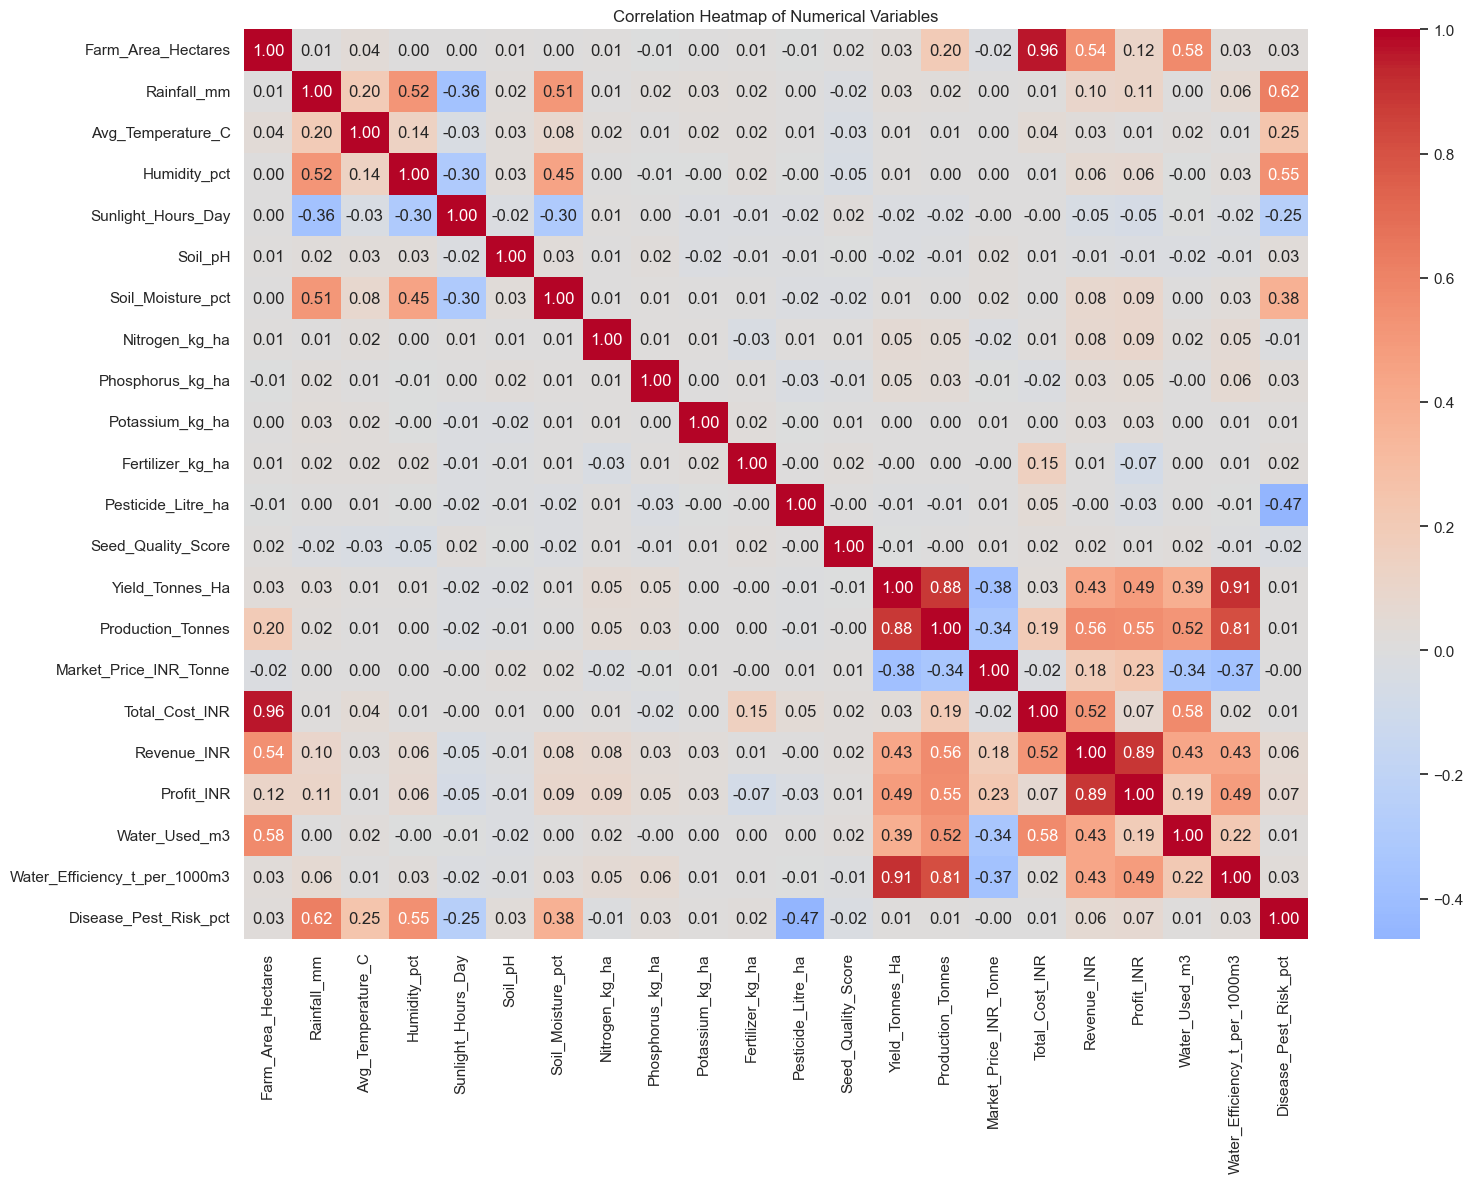

In [58]:
# Correlation heatmap for numerical variables
plt.figure(figsize=(16, 12))
corr = df[numeric_columns].corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

# 12.Seasonal Comparison

In [59]:
# General seasonal summary
season_metrics = df.groupby("Season").agg(
    Records=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Profit=("Profit_INR", "mean"),
    Total_Profit=("Profit_INR", "sum"),
    Average_Water_Used=("Water_Used_m3", "mean")
).round(2)

season_metrics

,Records,Average_Yield,Total_Production,Average_Profit,Total_Profit,Average_Water_Used
Season,,,,,,
Kharif,1779,5.63,"82,387.61","178,914.65",318289158,"6,102.20"
Rabi,1627,5.04,"67,498.88","87,689.47",142670768,"5,846.99"
Zaid,594,4.64,"23,098.35","-24,804.82",-14734066,"6,419.89"


In [60]:
# Additional seasonal summary: risk and efficiency
season_metrics_2 = df.groupby("Season").agg(
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Disease_Risk=("Disease_Pest_Risk_pct", "mean"),
    Pct_Loss_Making_Farms=("Profit_INR", lambda x: round((x < 0).mean() * 100, 1))
).round(2)

season_metrics_2

,Avg_Water_Efficiency,Avg_Disease_Risk,Pct_Loss_Making_Farms
Season,,,
Kharif,5.89,54.47,42.20
Rabi,5.19,40.48,51.10
Zaid,4.41,38.22,64.50


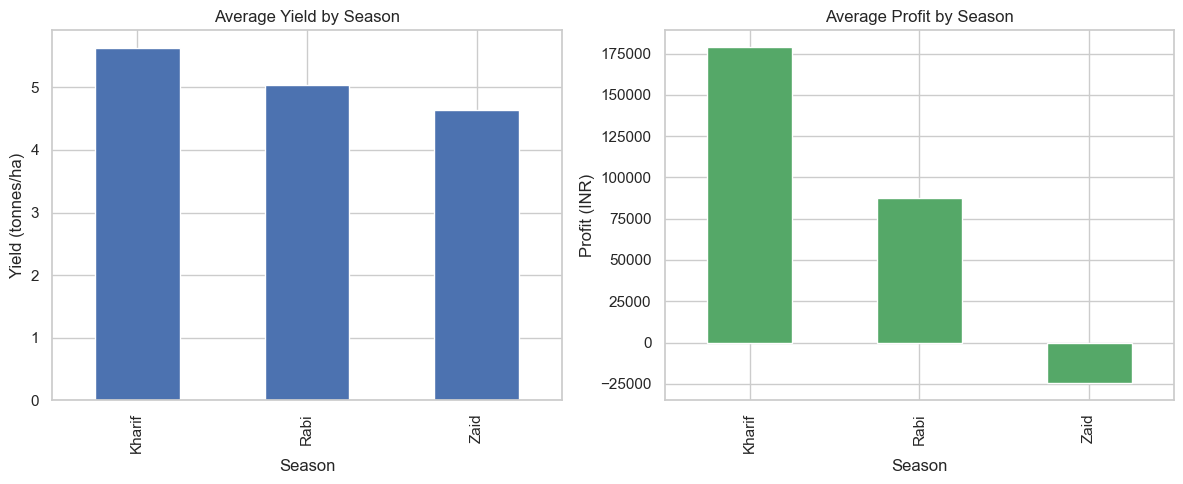

In [61]:
# Visual comparison: Yield and Profit across seasons
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
season_metrics["Average_Yield"].plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Average Yield by Season")
axes[0].set_ylabel("Yield (tonnes/ha)")

season_metrics["Average_Profit"].plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Average Profit by Season")
axes[1].set_ylabel("Profit (INR)")

plt.tight_layout()
plt.show()

### Interpretation

Kharif is the strongest season overall — it has the highest average yield, the
highest average profit, and the best water efficiency of the three seasons.

Zaid is the weakest economically: it is the only season with a negative average
profit, and roughly 64% of Zaid farms operate at a loss, compared to about 51%
in Rabi and 42% in Kharif.

Interestingly, Kharif also carries the highest disease/pest risk of the three
seasons — its strong performance happens despite higher disease pressure, not
because of lower pressure.

# 13.Questions

In [68]:

# Question: Do states with higher disease/pest risk actually earn less profit,
# or does risk not translate into worse outcomes?
# Analysis:

state_risk_profit = df.groupby("State").agg(
    Avg_Disease_Risk=("Disease_Pest_Risk_pct", "mean"),
    Avg_Profit=("Profit_INR", "mean")
).round(2).sort_values("Avg_Disease_Risk", ascending=False)

state_risk_profit

,Avg_Disease_Risk,Avg_Profit
State,,
Madhya Pradesh,47.08,"86,840.76"
Andhra Pradesh,46.72,"73,453.53"
Maharashtra,46.44,"135,428.86"
Telangana,46.36,"108,829.62"
Tamil Nadu,46.28,"117,744.75"
Karnataka,46.06,"119,422.34"
Punjab,46.00,"136,025.64"
Gujarat,45.95,"117,568.24"


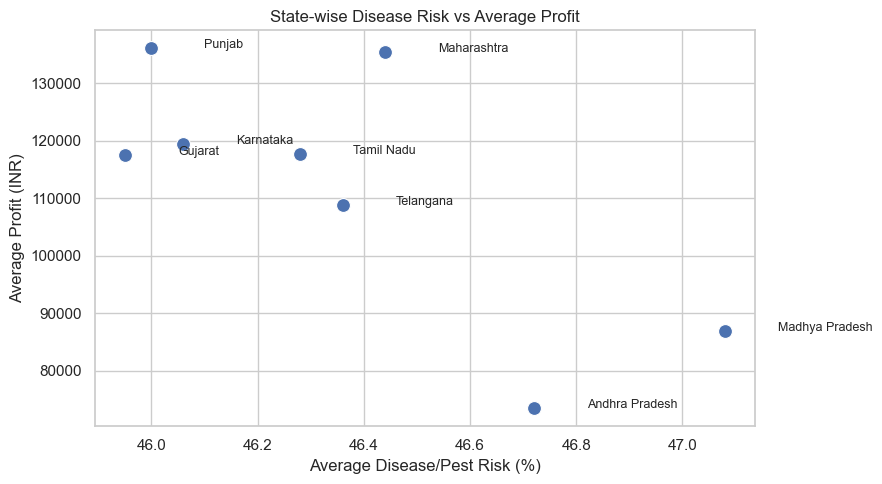

In [64]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=state_risk_profit, x="Avg_Disease_Risk", y="Avg_Profit", s=100)
for state in state_risk_profit.index:
    plt.text(state_risk_profit.loc[state, "Avg_Disease_Risk"] + 0.1,
              state_risk_profit.loc[state, "Avg_Profit"], state, fontsize=9)
plt.title("State-wise Disease Risk vs Average Profit")
plt.xlabel("Average Disease/Pest Risk (%)")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()

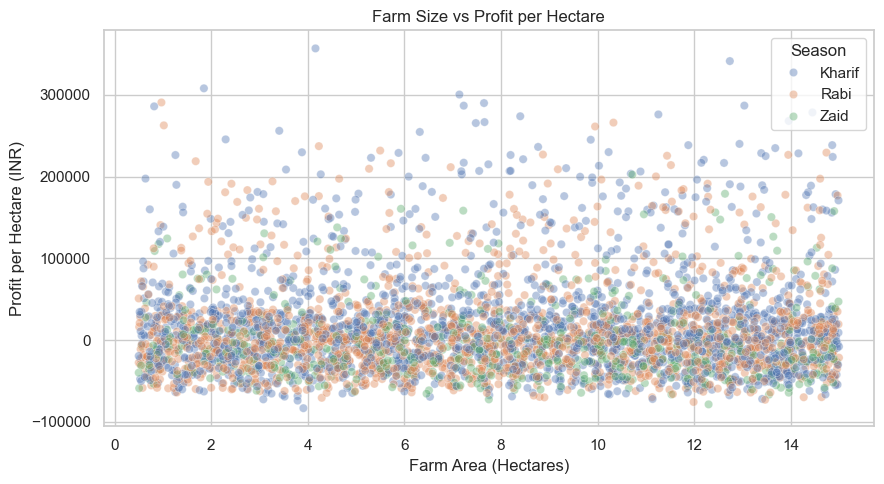

Correlation (Farm Area vs Profit/Hectare): 0.019


In [69]:

# Question: Are larger farms more profitable per hectare, or does profitability
# per unit area stay flat regardless of farm size?
# Analysis:

df["Profit_per_Hectare"] = df["Profit_INR"] / df["Farm_Area_Hectares"]

plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x="Farm_Area_Hectares", y="Profit_per_Hectare", hue="Season", alpha=0.4)
plt.title("Farm Size vs Profit per Hectare")
plt.xlabel("Farm Area (Hectares)")
plt.ylabel("Profit per Hectare (INR)")
plt.tight_layout()
plt.show()

print("Correlation (Farm Area vs Profit/Hectare):", df["Farm_Area_Hectares"].corr(df["Profit_per_Hectare"]).round(3))

In [70]:

# Question: Beyond average profit, which crop-season combinations are the most
# volatile/unpredictable (highest risk), even if their average profit looks okay?
# Analysis:

risk_table = df.groupby(["Season", "Crop"])["Profit_INR"].agg(["mean", "std"]).round(0)
risk_table["Risk_Ratio"] = (risk_table["std"] / risk_table["mean"].abs()).round(2)
risk_table.sort_values("Risk_Ratio", ascending=False).head(8)

mean        std  Risk_Ratio
Season Crop                                       
Rabi   Groundnut  10,417.00 273,028.00       26.21
       Pulses    -14,309.00 261,233.00       18.26
Kharif Pulses     43,339.00 321,484.00        7.42
       Maize     -39,333.00 260,007.00        6.61
Zaid   Cotton    -53,925.00 290,370.00        5.38
Kharif Rice      -64,903.00 274,828.00        4.23
Zaid   Groundnut -68,872.00 264,222.00        3.84
Rabi   Cotton    107,344.00 327,583.00        3.05

## 14. Key Insights

**1. Kharif outperforms the other seasons on yield and profit.**
- Observation: Kharif has the highest average yield (~5.63 t/ha) and highest average profit (~₹1.79 lakh) of the three seasons.
- Evidence: Section 12 seasonal summary table (Average_Yield, Average_Profit by Season).
- Interpretation: Kharif appears to be the most productive and profitable season overall for this dataset.
- Limitation: This is an average across all crops/states combined — it does not mean every crop or region performs best in Kharif specifically.

**2. Zaid is the only season with a negative average profit.**
- Observation: Zaid's average profit is negative, and ~64.5% of Zaid farms operate at a loss, versus ~51% in Rabi and ~42% in Kharif.
- Evidence: season_metrics_2 table (Pct_Loss_Making_Farms by Season).
- Interpretation: Zaid carries the highest financial risk of the three seasons for the farms in this dataset.
- Limitation: Loss doesn't necessarily mean the season is unviable everywhere — it may be concentrated in specific crops or states rather than uniform across all Zaid farming.

**3. Seasonal differences are statistically significant, not just visual noise.**
- Observation: Yield, production, profit, water efficiency and disease/pest risk all differ significantly across seasons.
- Evidence: Kruskal-Wallis test results (Section 9), all p < 0.001.
- Interpretation: The seasonal patterns observed in this dataset are unlikely to be due to random chance.
- Limitation: Statistical significance confirms a real difference exists, but not the size of its practical impact or its cause.

**4. Kharif has the highest disease/pest risk, despite also having the best output.**
- Observation: Kharif's average disease/pest risk (~54.5%) is the highest of the three seasons, while Zaid's is the lowest (~38.2%).
- Evidence: season_metrics_2 table (Avg_Disease_Risk by Season).
- Interpretation: Kharif's strong yield/profit performance occurs alongside higher disease pressure, not because of lower disease pressure.
- Limitation: This is an association, not proof that disease risk and yield are causally linked — other factors could independently affect both.

**5. Farming inputs (fertilizer, N/P/K, pesticide, seed quality) show almost no correlation with yield.**
- Observation: All correlation coefficients between these inputs and Yield_Tonnes_Ha are below |0.06|.
- Evidence: Correlation heatmap and Student Analysis (input_corr) in Section 10/13.
- Interpretation: Within the range of values present in this dataset, higher input levels are not associated with higher yield.
- Limitation: A weak linear correlation does not rule out a non-linear relationship, threshold effects, or interaction with other unmeasured variables.

**6. Irrigation method affects water efficiency more than season does.**
- Observation: Rainfed farming shows the highest water-efficiency ratio (~7.56 t/1000m³) and Flood the lowest (~3.44), while this ranking holds consistently across all three seasons.
- Evidence: Section 10 bivariate analysis (Water Efficiency by Irrigation Method).
- Interpretation: Irrigation method choice appears to be a stronger driver of water efficiency than which season the crop is grown in.
- Limitation: A high efficiency ratio for Rainfed partly reflects that little or no water is applied at all, not necessarily "better" farming outcomes.

**7. The best-performing season is not the same for every state.**
- Observation: Karnataka's best-yielding season is Zaid and Maharashtra/Punjab's is Rabi, while the other five states peak in Kharif.
- Evidence: State × Season yield heatmap (Section 11 multivariate analysis).
- Interpretation: The "Kharif is best" pattern seen in the overall averages does not hold universally across all states.
- Limitation: State-level averages can be influenced by which crops are most commonly grown in that state, not season alone.

**8. Profitability is driven more by the crop-season combination than by the crop alone.**
- Observation: Rice, Maize and Wheat are all sharply loss-making specifically in Zaid, while Sugarcane and Chilli are strongly profitable specifically in Kharif/Rabi.
- Evidence: Season × Crop profit heatmap (Section 10/13 bivariate and student-designed analysis).
- Interpretation: The same crop can swing from profitable to loss-making depending on which season it is grown in.
- Limitation: This reflects the specific data collected here and may not generalize to other years, price conditions, or growing regions.

## 15. Evidence-Based Recommendations

1. **De-prioritize Zaid-season Rice, Maize and Wheat.** These combinations are consistently loss-making (Insight 8); shifting that land to Kharif/Rabi Sugarcane or Chilli where feasible would materially improve profitability.
2. **Investigate disease/pest management specifically for Kharif.** It leads on yield and profit but also carries the highest disease/pest risk (Insight 4); reducing this could push profitability even higher.
3. **Re-evaluate fertilizer and pesticide spending.** Since these inputs show almost no correlation with yield (Insight 5), budgets may be better redirected toward factors not captured in this dataset.
4. **Review Flood-irrigated farms for a method switch.** Flood has the lowest water-efficiency ratio of all methods, consistently across seasons (Insight 6).
5. **Give state-specific seasonal guidance rather than one blanket rule.** Karnataka, Maharashtra and Punjab don't follow the overall "Kharif is best" pattern (Insight 7).

## 16. Limitations

- The dataset does not explain why yield is largely uncorrelated with recorded inputs — unrecorded factors (technique, timing, seed variety, micro-climate) may be driving output.
- Missing values were imputed with median/mode (season-wise for Yield), which is reasonable but can understate real variability.
- The data is a single cross-sectional snapshot, not a multi-year time series, so these seasonal patterns may not hold in other years.
- Negative-profit rows were treated as genuine based on internal cost/revenue consistency, not independently verified against an external source.
- State- and crop-season-level findings rely on averages, which can be skewed by a small number of large-farm outliers.

## 17. Final Conclusion

Seasonal variation has a clear, statistically significant effect on agricultural performance in this dataset. Kharif is the strongest season overall, while Zaid is the weakest, with the only negative average profit and the highest share of loss-making farms. This gap is not explained by farming inputs or environmental variables recorded here, since none show a meaningful correlation with yield — the true driver remains unexplained by this dataset. The clearest, best-supported action is season- and state-specific crop planning: shifting loss-making crop-season combinations toward the seasons and crops that consistently perform well, rather than uniform, season-blind resource allocation.